In [1]:
import seaborn as sns 
diamonds = sns.load_dataset("diamonds")

In [2]:
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [3]:
diamonds.sample(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
3034,0.41,Good,J,VS2,64.0,59.0,565,4.64,4.71,2.99
37086,0.41,Premium,E,SI1,60.5,61.0,969,4.80,4.78,2.90
37264,0.29,Very Good,E,VS1,61.4,61.0,481,4.22,4.25,2.60
42884,0.50,Ideal,E,SI2,60.7,56.0,1359,5.16,5.19,3.14
18687,1.00,Premium,G,VVS1,61.3,62.0,7644,6.37,6.35,3.90


In [4]:
numeric = diamonds.select_dtypes(include=["float64", "int64"]).columns.tolist()
pearson_corr = diamonds[numeric].corr(method="pearson")
spearman_corr = diamonds[numeric].corr(method="spearman")

In [5]:
pearson_corr

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


In [6]:
spearman_corr

,carat,depth,table,price,x,y,z
carat,1.000000,0.030104,0.194980,0.962883,0.996117,0.995572,0.993183
depth,0.030104,1.000000,-0.245061,0.010020,-0.023442,-0.025425,0.103498
table,0.194980,-0.245061,1.000000,0.171784,0.202231,0.195734,0.159878
price,0.962883,0.010020,0.171784,1.000000,0.963196,0.962719,0.957232
x,0.996117,-0.023442,0.202231,0.963196,1.000000,0.997895,0.987355
y,0.995572,-0.025425,0.195734,0.962719,0.997895,1.000000,0.987068
z,0.993183,0.103498,0.159878,0.957232,0.987355,0.987068,1.000000


<Axes: >

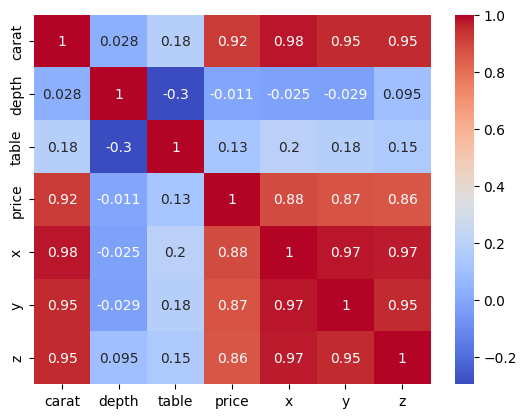

In [7]:
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm")

<Axes: >

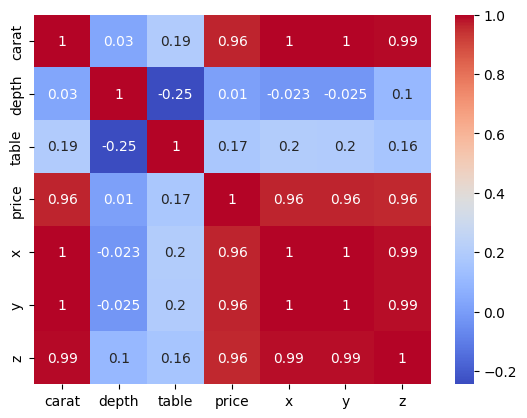

In [8]:
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm")

In [9]:
import matplotlib.pyplot as plt

In [10]:
sns.set(style="whitegrid")

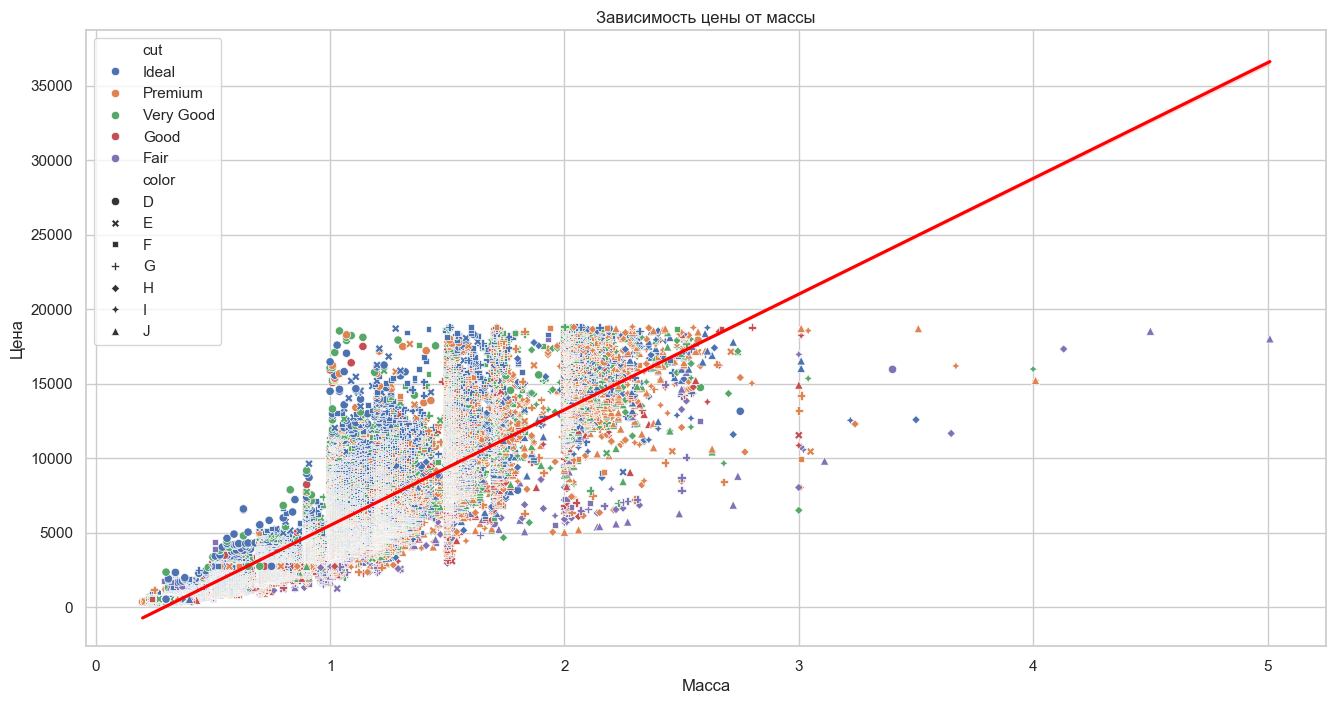

In [11]:
plt.figure(figsize=(16, 8))

sns.scatterplot(
    data=diamonds,
    x="carat",
    y="price",
    hue="cut",
    style="color"
)

sns.regplot(
    data=diamonds,
    x="carat",
    y="price",
    scatter=False,
    color="red"
)

plt.title("Зависимость цены от массы")
plt.xlabel("Масса")
plt.ylabel("Цена")

plt.show()

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = diamonds[["carat"]]
y = diamonds["price"]

In [13]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
a, b = model.intercept_, model.coef_[0]

In [15]:
a, b

(np.float64(-2256.3605800457585), np.float64(7756.42561796888))

In [16]:
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)

r2

0.8493305264354858

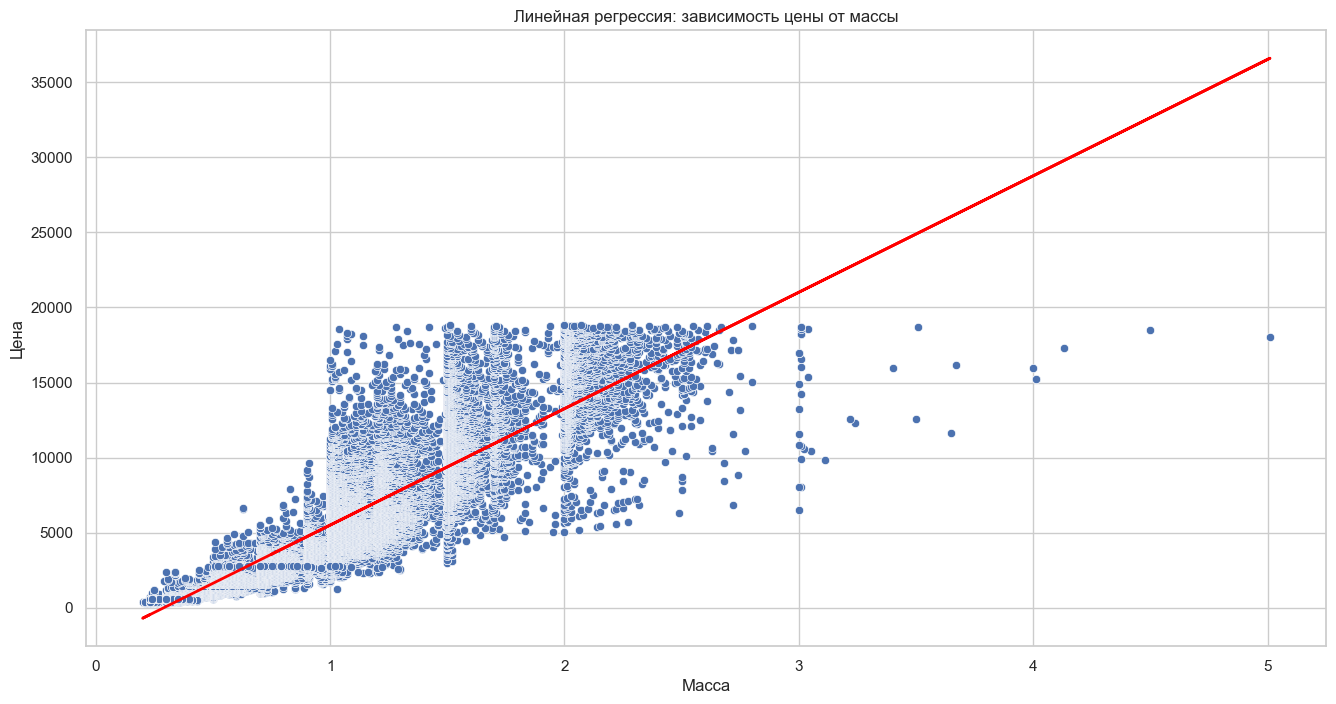

In [17]:
plt.figure(figsize=(16, 8))

sns.scatterplot(
    data=diamonds,
    x="carat",
    y="price"
)

plt.plot(
    X,
    y_pred,
    color="red",
    linewidth=2
)

plt.title("Линейная регрессия: зависимость цены от массы")
plt.xlabel("Масса")
plt.ylabel("Цена")
plt.show()

In [18]:
residuals = y - y_pred

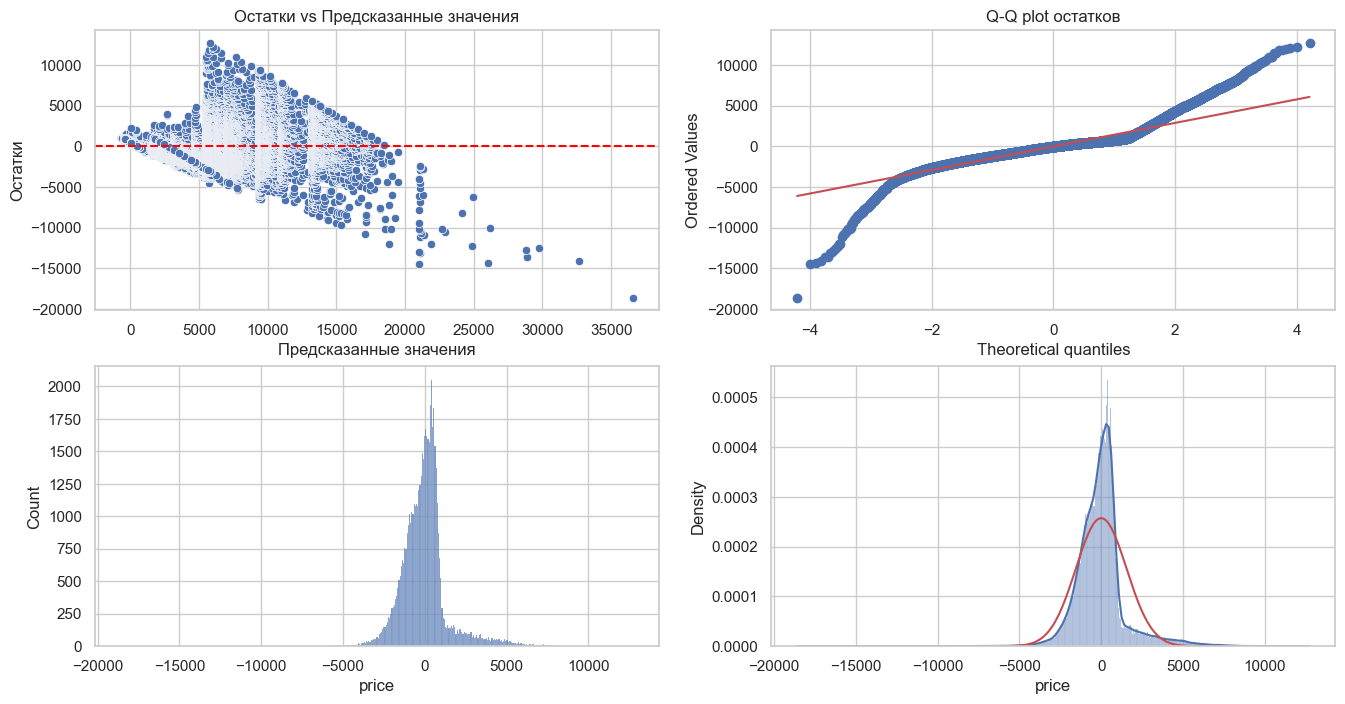

In [19]:
from scipy import stats
import numpy as np

plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(0, color="red", linestyle="--")

plt.title("Остатки vs Предсказанные значения")
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")

stats.probplot(residuals, dist="norm", plot=plt.subplot(2, 2, 2))

plt.title("Q-Q plot остатков")

plt.subplot(2, 2, 3)
sns.histplot(residuals)

mu, std = stats.norm.fit(residuals)

plt.subplot(2, 2, 4)

sns.histplot(residuals, stat="density", kde=True)

x = np.linspace(min(residuals), max(residuals), 200)
plt.plot(x, stats.norm.pdf(x, mu, std), 'r')

plt.show()

plt.show()

In [20]:
_, p_value = stats.anderson(residuals, method="interpolate")

p_value

np.float64(0.01)

In [21]:
from statsmodels.stats.diagnostic import het_breuschpagan
import numpy as np
import pandas as pd

Xs = np.column_stack([np.ones(X.shape[0]), X])

bp_test = het_breuschpagan(
    residuals,
    Xs
)

In [22]:
results = pd.DataFrame(bp_test, ["LM Statistic", "LM-Test p-value", "F-Statistic", "F-Test p-value"])

results

,0
LM Statistic,9131.227815
LM-Test p-value,0.000000
F-Statistic,10991.601463
F-Test p-value,0.000000
